딥러닝을 이용해 가상의 이미지를 만드는 또 하나의 유명한 알고리즘이 있다. 바로 오토인코더(Auto-Encoder, AE)이다.

GAN이 세상에 존재하지 않는 완전한 가상의 것을 만들어 내는 반면에, 오토인코더는 입력 데이터의 특징을 효율적으로 담아낸 이미지를 만들어 낸다. 오토인코더는 아직 데이터 수가 충분하지 않은 분야에서 사용될 수 있다. 부족한 학습 데이터 수를 효과적으로 늘려 주는 효과를 기대할 수 있다.

오토인코더는 입력한 이미지와 똑같은 크기로 출력층을 만들고 입력층보다 적은 수의 노드를 가진 은닉층을 중간에 넣어서 차원을 줄여 준다. 이때 소실된 데이터를 복원하기 위해 학습을 시작하고, 이 과정을 통해 입력 데이터의 특징을 효율적으로 응축한 새로운 출력이 나오는 원리이다.

가장 핵심이 되는 인코딩과 디코딩 과정을 코딩해 보면 다음과 같다.

In [1]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Reshape

# 생성자 모델 만들기
autoencoder = Sequential()

# 인코딩 부분
autoencoder.add(Conv2D(16, kernel_size=3, padding='same', input_shape=(28,28,1),
                       activation='relu'))
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
autoencoder.add(Conv2D(8, kernel_size=3, activation='relu', padding='same'))
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
autoencoder.add(Conv2D(8, kernel_size=3, strides=2, padding='same',
                       activation='relu'))

# 디코딩 부분
autoencoder.add(Conv2D(8, kernel_size=3, padding='same',
                       activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(8, kernel_size=3, padding='same',
                       activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(16, kernel_size=3, activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(1, kernel_size=3, padding='same',
                   activation='sigmoid'))

# 전체 구조 확인
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 8)         1160      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 8)           0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 4, 4, 8)           584       
                                                                 
 conv2d_3 (Conv2D)           (None, 4, 4, 8)           5

입력된 값의 차원 축소시키는 인코딩 부분은 다음과 같다.

```
autoencoder.add(Conv2D(16, kernel_size=3, padding='same', input_shape=(28,28,1),
                       activation='relu'))
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
autoencoder.add(Conv2D(8, kernel_size=3, activation='relu', padding='same'))
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
autoencoder.add(Conv2D(8, kernel_size=3, strides=2, padding='same',
                       activation='relu'))
```

다시 차원을 점차 늘려 입력 값과 똑같은 크기의 출력 값을 내보내는 디코딩 부분은 다음과 같다.


```
autoencoder.add(Conv2D(8, kernel_size=3, padding='same',
                       activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(8, kernel_size=3, padding='same',
                       activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(16, kernel_size=3, activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(1, kernel_size=3, padding='same',
                   activation='sigmoid'))
```

입력된 값은 MaxPooling 층을 지나면서 절반씩 줄어들고, UpSampling 층을 지나면서 두배로 늘어난다.  


```
autoencoder.add(Conv2D(16, kernel_size=3, activation='relu'))
```
위의 층은 다른 Conv2D 층과 달리 벡터 값이 줄어들었음에 주의해야 한다. Conv2D 층에는 padding이 적용되지 않았고 kernel_size=3이 설정되었으므로 3x3 커널이 훑고 지나가면서 벡터의 차원을 2만큼 줄였다.
  

마지막 층의 벡터 값이 처음 입력 값과 같은 28x28 크기가 되는 것을 확인하면 모든 준비가 된 것이다.


실습| 오토인코더 실습하기

11490434/11490434 [==============================] - 0s 0us/step
Epoch 1/50
469/469 [==============================] - 22s 10ms/step - loss: 0.2091 - val_loss: 0.1428
Epoch 2/50
469/469 [==============================] - 3s 7ms/step - loss: 0.1293 - val_loss: 0.1187
Epoch 3/50
469/469 [==============================] - 4s 8ms/step - loss: 0.1152 - val_loss: 0.1097
Epoch 4/50
469/469 [==============================] - 4s 8ms/step - loss: 0.1084 - val_loss: 0.1045
Epoch 5/50
469/469 [==============================] - 3s 7ms/step - loss: 0.1043 - val_loss: 0.1014
Epoch 6/50
469/469 [==============================] - 3s 7ms/step - loss: 0.1013 - val_loss: 0.0986
Epoch 7/50
469/469 [==============================] - 4s 8ms/step - loss: 0.0989 - val_loss: 0.0966
Epoch 8/50
469/469 [==============================] - 3s 7ms/step - loss: 0.0969 - val_loss: 0.0947
Epoch 9/50
469/469 [==============================] - 3s 7ms/step - loss: 0.0954 - val_loss: 0.0933
Epoch 10/50
469/469 [============

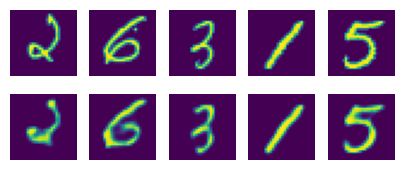

In [2]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Reshape

import matplotlib.pyplot as plt
import numpy as np

# MNIST 데이터셋을 불러온다.
(X_train, _), (X_test, _) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

# 생성자 모델을 만든다.
autoencoder = Sequential()

# 인코딩 부분이다.
autoencoder.add(Conv2D(16, kernel_size=3, padding='same', input_shape=(28, 28, 1),
                       activation='relu'))
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
autoencoder.add(Conv2D(8, kernel_size=3, activation='relu', padding='same'))
autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
autoencoder.add(Conv2D(8, kernel_size=3, strides=2, padding='same',
                       activation='relu'))

# 디코딩 부분이다.
autoencoder.add(Conv2D(8, kernel_size=3, padding='same',
                       activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(8, kernel_size=3, padding='same',
                       activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(16, kernel_size=3, activation='relu'))
autoencoder.add(UpSampling2D())
autoencoder.add(Conv2D(1, kernel_size=3, padding='same',
                       activation='sigmoid'))

# 컴파일 및 학습을 하는 부분이다.
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(X_train, X_train, epochs=50, batch_size=128,
                validation_data=(X_test, X_test))

# 학습된 결과를 출력하는 부분이다.
random_test = np.random.randint(X_test.shape[0], size=5)

# 테스트할 이미지를 랜덤으로 호출한다.
ae_imgs = autoencoder.predict(X_test) # 앞서 만든 오토인코더 모델에 넣는다.

plt.figure(figsize=(7,2)) # 출력 이미지의 크기를 정한다.

for i, image_idx in enumerate(random_test):
    # 랜덤으로 뽑은 이미지를 차례로 나열한다.
    ax = plt.subplot(2, 7, i+1)
    # 테스트할 이미지를 먼저 그대로 보여 준다.
    plt.imshow(X_test[image_idx].reshape(28, 28))
    ax.axis('off')
    ax = plt.subplot(2, 7, 7+i+1)
    # 오토인코딩 결과를 다음 열에 입력한다.
    plt.imshow(ae_imgs[image_idx].reshape(28, 28))
    ax.axis('off')
plt.show()